## Customer Purchase Propensity - Data Cleaning and Feature Engineering Pipeline

Project Planning & Problem Framing

1.What is Data Analysis?  

->Data Analysis is the process of inspecting, cleaning, transforming, and interpreting raw data to discover useful patterns, trends, and insights that support decision-making.
It involves collecting data, exploring it (EDA), checking for missing values/outliers, and summarizing findings using statistics or visualizations.



2.Steps in a Data Science Project

-Problem Definition – Understand the business question and define the goal (e.g., predict, classify, or explain something).

-Data Collection – Gather relevant data from files, databases, or APIs.

-Data Cleaning & Preprocessing – Handle missing values, duplicates, outliers, and encode/scale features.

-Exploratory Data Analysis (EDA) – Visualize and analyze data to understand relationships and patterns.

-Model Building – Select and train a suitable machine learning algorithm.

-Model Evaluation – Test performance using metrics.

-Deployment & Communication – Deploy the model or present results/insights to stakeholders.



3.How to frame this dataset as a Machine Learning problem (binary classification).

->Identify the target variable — it should have exactly two possible outcomes (e.g., Yes/No, 0/1, Survived/Not Survived).
-Treat all other relevant columns as input features that help predict this target.
-Choose classification algorithms (e.g., Logistic Regression, Decision Tree, Random Forest) suited to binary outcomes, and evaluate using metrics like accuracy, confusion matrix, precision, and recall.

In [185]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [186]:
## Data Importing 

##CSV 

df=pd.read_csv("customers.csv")
df

,customer_id,name,age,gender,city,income,education,satisfaction_level,signup_date,last_purchase_date
0,1001,Karan,65.0,M,Delhi,61000.0,High School,Low,NaN,2024-06-01
1,1002,Aadhya,35.0,FEMALE,Indore,37500.0,Bachelor's,Medium,16/03/2020,NaN
2,1003,Shaurya,20.0,M,Nagpur,45000.0,PhD,Medium,20/06/2022,2024-12-22
3,CUST-1004A,Aryan,24.0,M,Kolkata,60500.0,Master's,Medium,2020-06-30,25-06-2023
4,1005,Dhruv,21.0,male,Ahmedabad,42000.0,PhD,Low,07/03/2022,2024/05/26
...,...,...,...,...,...,...,...,...,...,...
795,1796,Sahil,21.0,male,Chennai,39500.0,Master's,Low,28/04/2023,23-12-2023
796,1797,Anika,65.0,F,Indore,22000.0,Master's,High,11/04/2021,16-10-2024
797,1798,Rudra,46.0,MALE,Kochi,25500.0,Bachelor's,Low,27/09/2020,05-07-2024
798,1799,Riya,56.0,female,Kochi,51500.0,Master's,Medium,23-03-2021,17/04/2023


In [187]:
## JSON 

df_json=pd.read_json("transactions.json")
df_json

,transaction_id,customer_id,product_id,transaction_date,quantity,amount,purchased
0,T00001,1574,P015,2024-04-07,5.0,9448.97,1
1,T00002,1458,P010,2023-05-26,1.0,1310.45,1
2,T00003,CUST-1162A,P020,2023-01-16,1.0,59510.22,1
3,T00004,1476,P011,2024-03-27,2.0,4397.80,1
4,T00005,1285,P014,2024-07-18,1.0,314.43,1
...,...,...,...,...,...,...,...
2495,T02496,1668,P015,2023-12-22,50.0,61826.37,0
2496,T02497,1412,P017,2024-03-30,4.0,14288.15,1
2497,T02498,1625,P003,2024-12-31,3.0,8248.19,1
2498,T02499,1108,P005,2024-10-07,3.0,3731.40,1


In [188]:
## SQL 

import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345",
    database="practical"
)

query = "SELECT * FROM product"
df_sql = pd.read_sql(query, connection)
df_sql

C:\Users\Admin\AppData\Local\Temp\ipykernel_11292\469093073.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, connection)


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30
5,P006,Power Bank,Mobile Accessories,2599,20
6,P007,Wireless Mouse,Computer,599,80
7,P008,Fitness Band,Wearable,1499,35
8,P009,Laptop Stand,Computer,799,45
9,P010,Gaming Controller,Gaming,2199,22


In [189]:
## API 

import requests

response = requests.get("https://dummyjson.com/users")
data = response.json()

users = pd.json_normalize(data["users"])

print(users.head())




   id firstName  lastName maidenName  age  gender  \
0   1     Emily   Johnson      Smith   29  female   
1   2   Michael  Williams              36    male   
2   3    Sophia     Brown              43  female   
3   4     James     Davis              46    male   
4   5      Emma    Miller    Johnson   31  female   

                              email             phone  username      password  \
0     emily.johnson@x.dummyjson.com  +81 965-431-3024    emilys    emilyspass   
1  michael.williams@x.dummyjson.com  +49 258-627-6644  michaelw  michaelwpass   
2      sophia.brown@x.dummyjson.com  +81 210-652-2785   sophiab   sophiabpass   
3       james.davis@x.dummyjson.com  +49 614-958-9364    jamesd    jamesdpass   
4       emma.miller@x.dummyjson.com  +91 759-776-1614     emmaj     emmajpass   

   ... company.address.city company.address.state company.address.stateCode  \
0  ...        San Francisco             Wisconsin                        WI   
1  ...          Los Angeles         

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         800 non-null    object 
 1   name                800 non-null    object 
 2   age                 768 non-null    float64
 3   gender              774 non-null    object 
 4   city                800 non-null    object 
 5   income              737 non-null    float64
 6   education           765 non-null    object 
 7   satisfaction_level  753 non-null    object 
 8   signup_date         755 non-null    object 
 9   last_purchase_date  665 non-null    object 
dtypes: float64(2), object(8)
memory usage: 62.6+ KB


In [191]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,768.0,42.727865,19.006008,-5.0,29.0,41.0,54.0,200.0
income,737.0,55349.905020,63457.149399,740.0,36000.0,46000.0,55500.0,600000.0


In [192]:
df.head()

,customer_id,name,age,gender,city,income,education,satisfaction_level,signup_date,last_purchase_date
0,1001,Karan,65.0,M,Delhi,61000.0,High School,Low,NaN,2024-06-01
1,1002,Aadhya,35.0,FEMALE,Indore,37500.0,Bachelor's,Medium,16/03/2020,NaN
2,1003,Shaurya,20.0,M,Nagpur,45000.0,PhD,Medium,20/06/2022,2024-12-22
3,CUST-1004A,Aryan,24.0,M,Kolkata,60500.0,Master's,Medium,2020-06-30,25-06-2023
4,1005,Dhruv,21.0,male,Ahmedabad,42000.0,PhD,Low,07/03/2022,2024/05/26


In [193]:
gender_map = {
    "m": "Male", "male": "Male",
    "f": "Female", "female": "Female"
}

df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(gender_map)

print(df["gender"].value_counts(dropna=False))

gender
Female    400
Male      374
NaN        26
Name: count, dtype: int64


In [240]:
df["customer_id"] = df["customer_id"].astype(str).str.extract(r"(\d+)").astype(int)

In [194]:
## Explorately data analysis 

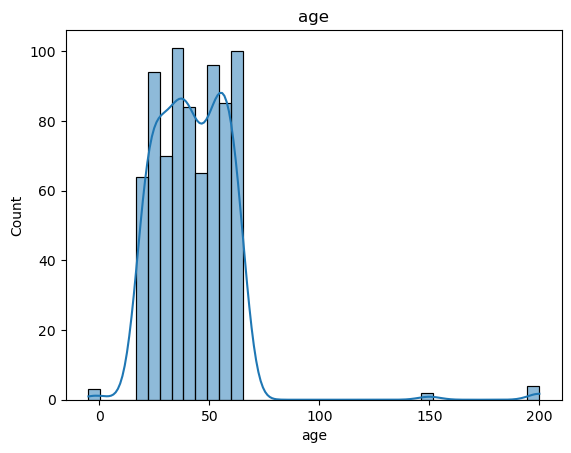

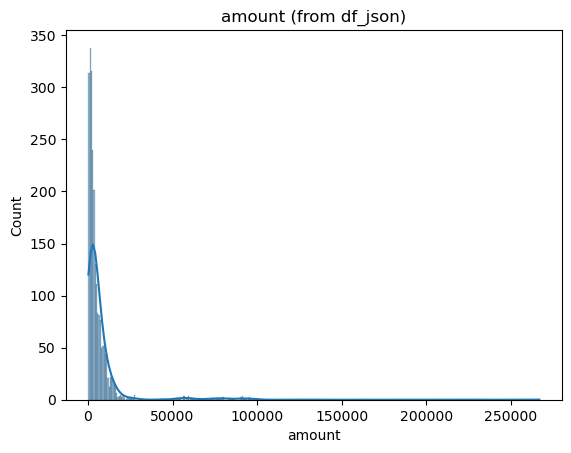

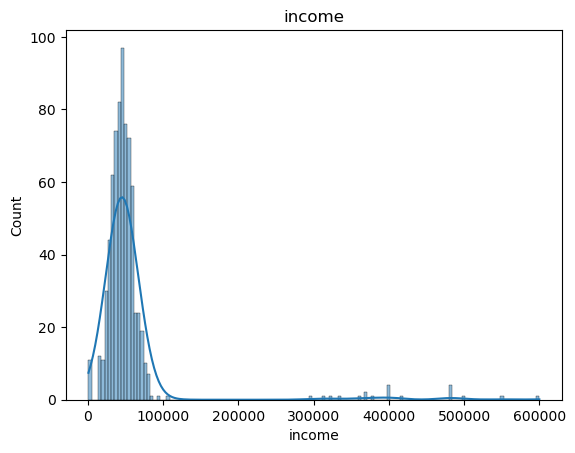

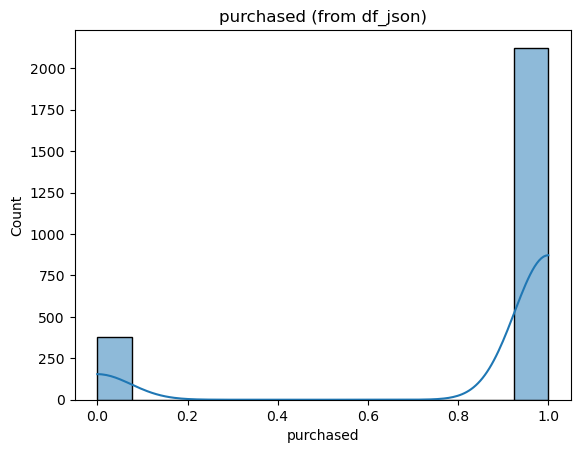

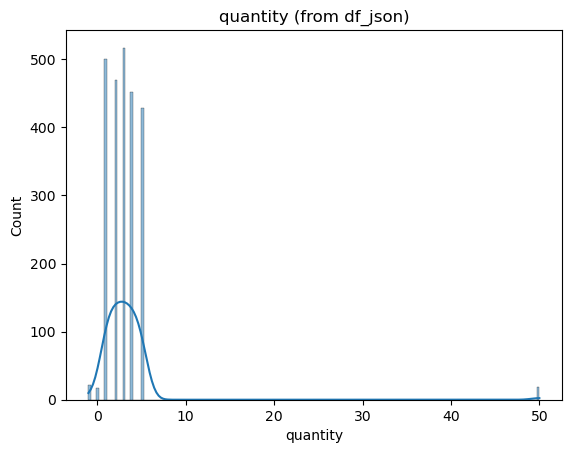

In [195]:
num_cols = df.select_dtypes("number").columns.union(df_json.select_dtypes("number").columns)

for col in num_cols:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()
    if col in df_json.columns :
        plt.figure()
        sns.histplot(df_json[col], kde=True)
        plt.title(f"{col} (from df_json)")
        plt.show()

In [196]:
from scipy.stats import skew

for col in num_cols:
    if col in df.columns:
        s = skew(df[col].dropna())
        print(f"{col}: skewness = {s:.2f}")

    if col in df_json.columns:
        s=skew(df_json[col].dropna())
        print(f"{col}: skewness = {s:.2f}")

age: skewness = 3.29
amount: skewness = 6.62
income: skewness = 5.74
purchased: skewness = -1.96
quantity: skewness = 9.54


In [197]:
from ydata_profiling import ProfileReport

ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/10 [00:00<?, ?it/s]
%|████████▎                                                                          | 1/10 [00:00<00:02,  4.05it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 24.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: >

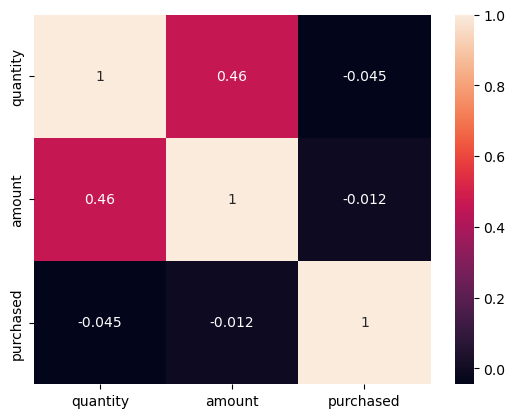

In [198]:
## Biaveriate analysis

numerical=df_json.select_dtypes("number").columns

sns.heatmap(df_json[numerical].corr(),annot=True)


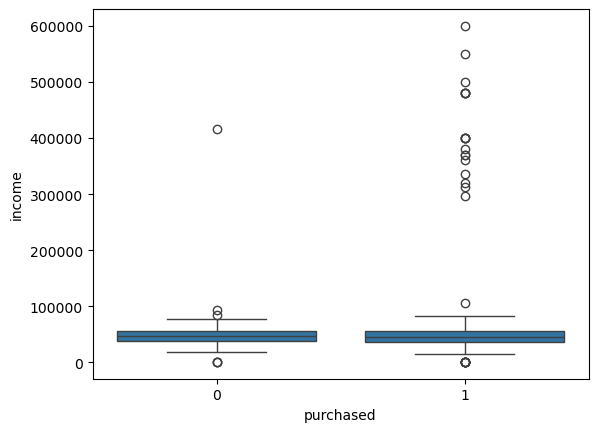

In [199]:
sns.boxplot(x=df_json["purchased"], y=df["income"])
plt.show()

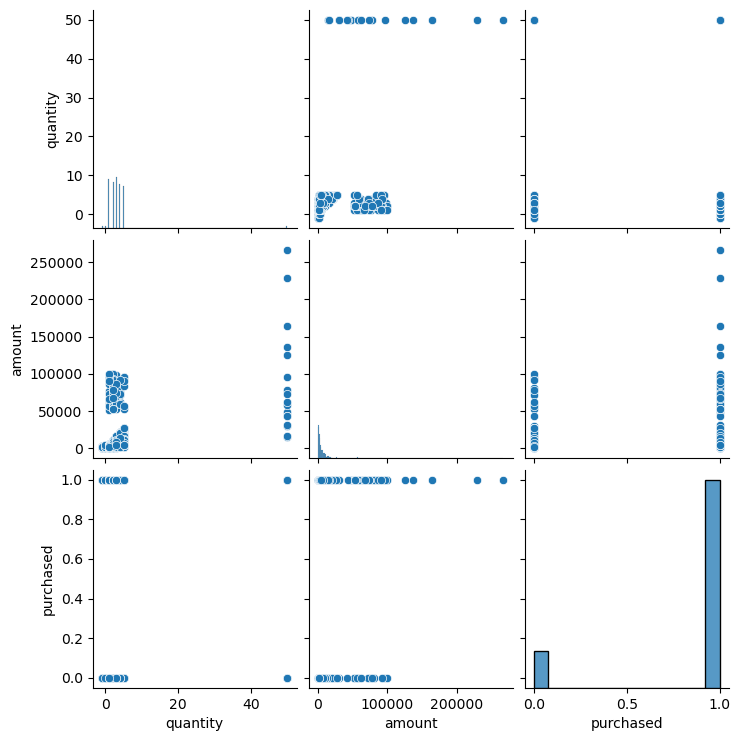

In [200]:
sns.pairplot(df_json)

In [201]:
## Handling Missing data 

df.isnull().sum()

customer_id             0
name                    0
age                    32
gender                 26
city                    0
income                 63
education              35
satisfaction_level     47
signup_date            45
last_purchase_date    135
dtype: int64

In [202]:
## simple imputer 

from sklearn.impute import SimpleImputer 

imputer_median=SimpleImputer(strategy="median")
df["age"]=imputer_median.fit_transform(df[["age"]])

In [203]:
imputer_mode=SimpleImputer(strategy="most_frequent")
df["gender"]=imputer_mode.fit_transform(df[["gender"]]).ravel()

In [204]:
df["education_missing"] = df["education"].isnull().astype(int)

non_missing_values = df["education"].dropna()
num_missing = df["education"].isnull().sum()

random_values = non_missing_values.sample(n=num_missing, replace=True, random_state=42)
random_values.index = df[df["education"].isnull()].index
df.loc[df["education"].isnull(), "education"] = random_values


In [205]:
from sklearn.impute import KNNImputer

num_cols=df.select_dtypes("number").columns

knn_imputer = KNNImputer(n_neighbors=5)
result = knn_imputer.fit_transform(df[num_cols])

df["income"] = pd.DataFrame(result, columns=num_cols, index=df.index)["income"]

In [206]:
mode_value = df["satisfaction_level"].mode()[0]
df["satisfaction_level"] = df["satisfaction_level"].fillna(mode_value)

In [207]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce", dayfirst=True, format="mixed")

median_signup = df["signup_date"].median()
df["signup_date"] = df["signup_date"].fillna(median_signup)

In [208]:
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"], errors="coerce", dayfirst=True, format="mixed")

df["last_purchase_date"] = df["last_purchase_date"].fillna(df["signup_date"])

In [209]:
df.isnull().sum()

customer_id           0
name                  0
age                   0
gender                0
city                  0
income                0
education             0
satisfaction_level    0
signup_date           0
last_purchase_date    0
education_missing     0
dtype: int64

In [210]:
## Outliers 

from scipy import stats

for i in num_cols:
    z_score=stats.zscore(df[i])

    outliers=df[abs(z_score)>3]
    print(f"{i} : {len(outliers)} found.")

age : 6 found.
income : 20 found.
education_missing : 35 found.


In [211]:
## IQR method

for col in num_cols :
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

    iqr=q3-q1

    upper_bound=q3+1.5*iqr
    lower_bound=q1-1.5*iqr

    lower_outliers=df[df[col] < lower_bound] 
    upper_outliers=df[df[col] > upper_bound]
    total=len(lower_outliers)+ len(upper_outliers)

    print(f"{col} Outliers : lower={len(lower_outliers)} , upper={len(upper_outliers)}, total={total}")

age Outliers : lower=0 , upper=6, total=6
income Outliers : lower=11 , upper=38, total=49
education_missing Outliers : lower=0 , upper=35, total=35


In [212]:
## Percentile mehtod 

for col in num_cols :
    lower_bound=df[col].quantile(0.01)
    upper_bound=df[col].quantile(0.99)

    lower=df[df[col] < lower_bound]
    upper=df[df[col] > upper_bound]
    total=len(lower)+ len(upper)

    print(f"{col} Outliers : lower={len(lower)} , upper={len(upper)}, total={total}")

age Outliers : lower=3 , upper=6, total=9
income Outliers : lower=8 , upper=8, total=16
education_missing Outliers : lower=0 , upper=0, total=0


In [213]:
from scipy.stats.mstats import winsorize

for col in num_cols: 
    df[col]=winsorize(df[col],limits=[0.05,0.05])

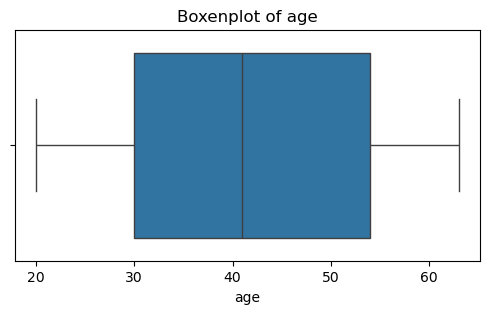

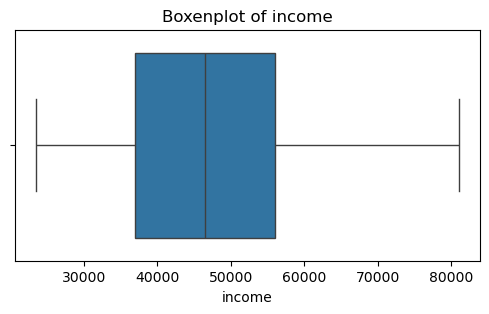

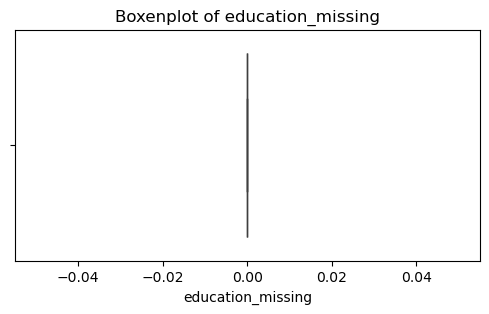

In [214]:
for col in num_cols:
    
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxenplot of {col}")
    plt.show()

In [215]:
reference_date = df["last_purchase_date"].max()   
df["days_since_last_purchase"] = (reference_date - df["last_purchase_date"]).dt.days

In [216]:
df["days_since_last_purchase"]

0       212
1      1750
2         8
3       554
4       218
       ... 
795     373
796      75
797     178
798     623
799     498
Name: days_since_last_purchase, Length: 800, dtype: int64

In [217]:
## encoding 

## Ordinal encoding 
df["education"].value_counts()

education
PhD            220
Master's       200
Bachelor's     194
High School    186
Name: count, dtype: int64

In [218]:
order={
    "High School":0,
    "Bachelor's":1, 
    "Master's":2, 
    "PhD":3
}

df["education_encoded"]=df["education"].map(order)
df[["education","education_encoded"]]



,education,education_encoded
0,High School,0
1,Bachelor's,1
2,PhD,3
3,Master's,2
4,PhD,3
...,...,...
795,Master's,2
796,Master's,2
797,Bachelor's,1
798,Master's,2


In [219]:
df["satisfaction_level"].value_counts()

satisfaction_level
High      319
Low       249
Medium    232
Name: count, dtype: int64

In [220]:
order={
    "Low":0,
    "Medium":1, 
    "High":2
}

df["satisfaction_level_encoded"]=df["satisfaction_level"].map(order)
df[["satisfaction_level","satisfaction_level_encoded"]]

,satisfaction_level,satisfaction_level_encoded
0,Low,0
1,Medium,1
2,Medium,1
3,Medium,1
4,Low,0
...,...,...
795,Low,0
796,High,2
797,Low,0
798,Medium,1


In [221]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [222]:
df["gender_encoded"] = le.fit_transform(df["gender"])
print(df[["gender", "gender_encoded"]].head())

   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3    Male               1
4    Male               1


In [223]:
## one hot encoding 

df = pd.get_dummies(df,columns=["city"], drop_first=False)

In [224]:
df

,customer_id,name,age,gender,income,education,satisfaction_level,signup_date,last_purchase_date,education_missing,...,city_Hyderabad,city_Indore,city_Jaipur,city_Kochi,city_Kolkata,city_Lucknow,city_Mumbai,city_Nagpur,city_Pune,city_Surat
0,1001,Karan,63.0,Male,61000.0,High School,Low,2021-05-18,2024-06-01,0,...,False,False,False,False,False,False,False,False,False,False
1,1002,Aadhya,35.0,Female,37500.0,Bachelor's,Medium,2020-03-16,2020-03-16,0,...,False,True,False,False,False,False,False,False,False,False
2,1003,Shaurya,20.0,Male,45000.0,PhD,Medium,2022-06-20,2024-12-22,0,...,False,False,False,False,False,False,False,True,False,False
3,CUST-1004A,Aryan,24.0,Male,60500.0,Master's,Medium,2020-06-30,2023-06-25,0,...,False,False,False,False,True,False,False,False,False,False
4,1005,Dhruv,21.0,Male,42000.0,PhD,Low,2022-03-07,2024-05-26,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1796,Sahil,21.0,Male,39500.0,Master's,Low,2023-04-28,2023-12-23,0,...,False,False,False,False,False,False,False,False,False,False
796,1797,Anika,63.0,Female,23500.0,Master's,High,2021-04-11,2024-10-16,0,...,False,True,False,False,False,False,False,False,False,False
797,1798,Rudra,46.0,Male,25500.0,Bachelor's,Low,2020-09-27,2024-07-05,0,...,False,False,False,True,False,False,False,False,False,False
798,1799,Riya,56.0,Female,51500.0,Master's,Medium,2021-03-23,2023-04-17,0,...,False,False,False,True,False,False,False,False,False,False


In [225]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer 
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[
    ("age_scaler", StandardScaler(), ["age"]),        
    ("income_scaler", RobustScaler(), ["income"])     
])

In [226]:
scaled_array = ct.fit_transform(df)
df[["age_scaled", "income_scaled"]] = scaled_array

In [227]:
df

,customer_id,name,age,gender,income,education,satisfaction_level,signup_date,last_purchase_date,education_missing,...,city_Jaipur,city_Kochi,city_Kolkata,city_Lucknow,city_Mumbai,city_Nagpur,city_Pune,city_Surat,age_scaled,income_scaled
0,1001,Karan,63.0,Male,61000.0,High School,Low,2021-05-18,2024-06-01,0,...,False,False,False,False,False,False,False,False,1.554243,0.763158
1,1002,Aadhya,35.0,Female,37500.0,Bachelor's,Medium,2020-03-16,2020-03-16,0,...,False,False,False,False,False,False,False,False,-0.500833,-0.473684
2,1003,Shaurya,20.0,Male,45000.0,PhD,Medium,2022-06-20,2024-12-22,0,...,False,False,False,False,False,True,False,False,-1.601767,-0.078947
3,CUST-1004A,Aryan,24.0,Male,60500.0,Master's,Medium,2020-06-30,2023-06-25,0,...,False,False,True,False,False,False,False,False,-1.308184,0.736842
4,1005,Dhruv,21.0,Male,42000.0,PhD,Low,2022-03-07,2024-05-26,0,...,False,False,False,False,False,False,False,False,-1.528371,-0.236842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1796,Sahil,21.0,Male,39500.0,Master's,Low,2023-04-28,2023-12-23,0,...,False,False,False,False,False,False,False,False,-1.528371,-0.368421
796,1797,Anika,63.0,Female,23500.0,Master's,High,2021-04-11,2024-10-16,0,...,False,False,False,False,False,False,False,False,1.554243,-1.210526
797,1798,Rudra,46.0,Male,25500.0,Bachelor's,Low,2020-09-27,2024-07-05,0,...,False,True,False,False,False,False,False,False,0.306518,-1.105263
798,1799,Riya,56.0,Female,51500.0,Master's,Medium,2021-03-23,2023-04-17,0,...,False,True,False,False,False,False,False,False,1.040474,0.263158


In [230]:
total_purchases = df_json.groupby("customer_id").size().rename("total_purchases")
df = df.merge(total_purchases, on="customer_id", how="left")
reference_date = pd.Timestamp("2024-12-31")
df["days_since_signup"] = (reference_date - df["signup_date"]).dt.days.replace(0, 1)
df["purchase_per_day"] = df["total_purchases"] / df["days_since_signup"]

In [231]:
df

,customer_id,name,age,gender,income,education,satisfaction_level,signup_date,last_purchase_date,education_missing,...,city_Lucknow,city_Mumbai,city_Nagpur,city_Pune,city_Surat,age_scaled,income_scaled,days_since_signup,total_purchases,purchase_per_day
0,1001,Karan,63.0,Male,61000.0,High School,Low,2021-05-18,2024-06-01,0,...,False,False,False,False,False,1.554243,0.763158,1323,2.0,0.001512
1,1002,Aadhya,35.0,Female,37500.0,Bachelor's,Medium,2020-03-16,2020-03-16,0,...,False,False,False,False,False,-0.500833,-0.473684,1751,2.0,0.001142
2,1003,Shaurya,20.0,Male,45000.0,PhD,Medium,2022-06-20,2024-12-22,0,...,False,False,True,False,False,-1.601767,-0.078947,925,NaN,NaN
3,CUST-1004A,Aryan,24.0,Male,60500.0,Master's,Medium,2020-06-30,2023-06-25,0,...,False,False,False,False,False,-1.308184,0.736842,1645,1.0,0.000608
4,1005,Dhruv,21.0,Male,42000.0,PhD,Low,2022-03-07,2024-05-26,0,...,False,False,False,False,False,-1.528371,-0.236842,1030,3.0,0.002913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1796,Sahil,21.0,Male,39500.0,Master's,Low,2023-04-28,2023-12-23,0,...,False,False,False,False,False,-1.528371,-0.368421,613,5.0,0.008157
796,1797,Anika,63.0,Female,23500.0,Master's,High,2021-04-11,2024-10-16,0,...,False,False,False,False,False,1.554243,-1.210526,1360,1.0,0.000735
797,1798,Rudra,46.0,Male,25500.0,Bachelor's,Low,2020-09-27,2024-07-05,0,...,False,False,False,False,False,0.306518,-1.105263,1556,2.0,0.001285
798,1799,Riya,56.0,Female,51500.0,Master's,Medium,2021-03-23,2023-04-17,0,...,False,False,False,False,False,1.040474,0.263158,1379,5.0,0.003626


In [233]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer


df["income_log"] = FunctionTransformer(np.log1p).transform(df[["income"]])
df["income_sqrt"] = FunctionTransformer(np.sqrt).transform(df[["income"]])
df["income_reciprocal"] = FunctionTransformer(lambda x: 1 / (x + 1)).transform(df[["income"]])

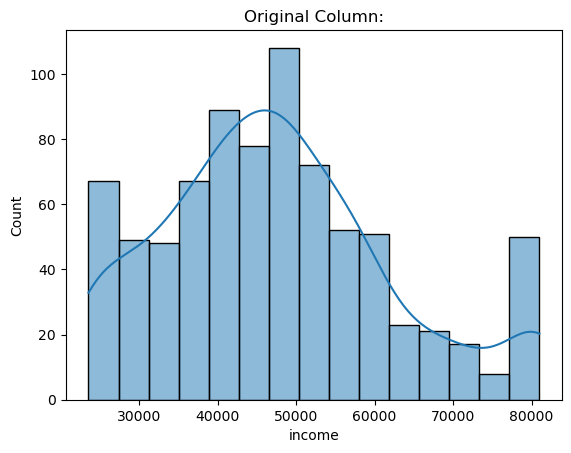

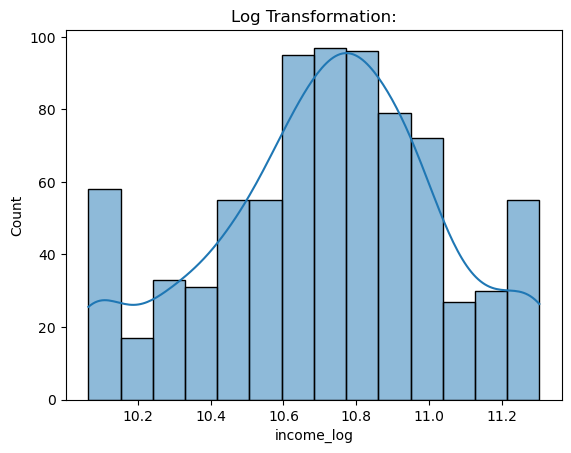

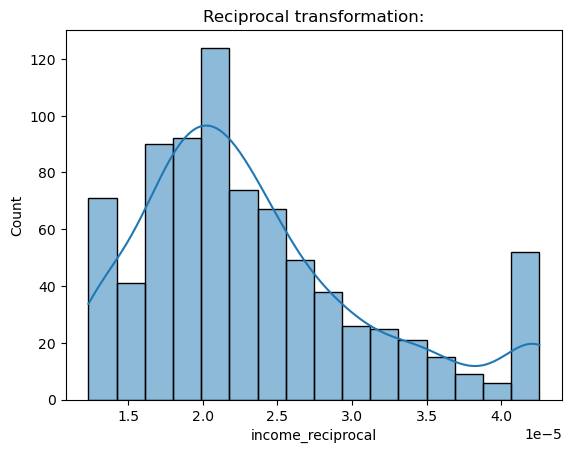

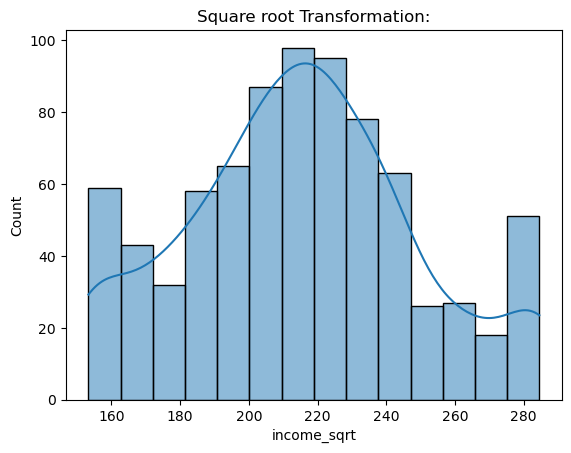

In [234]:
sns.histplot(df["income"],kde=True)
plt.title("Original Column:")
plt.show()

sns.histplot(df["income_log"],kde=True)
plt.title("Log Transformation:")
plt.show()

sns.histplot(df["income_reciprocal"],kde=True)
plt.title("Reciprocal transformation:")
plt.show()

sns.histplot(df["income_sqrt"],kde=True)
plt.title("Square root Transformation:")
plt.show()

In [235]:
df["income_boxcox"] = PowerTransformer(method="box-cox").fit_transform(df[["income"]])
df["income_yeojohnson"] = PowerTransformer(method="yeo-johnson").fit_transform(df[["income"]])

In [236]:
from sklearn.preprocessing import KBinsDiscretizer, Binarizer


df["income_bin_equalwidth"] = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="uniform").fit_transform(df[["income"]])
df["income_bin_quantile"] = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile").fit_transform(df[["income"]])

In [238]:

df["total_purchases"] = df["total_purchases"].fillna(0)
threshold = df["total_purchases"].median()
df["frequent_buyer"] = Binarizer(threshold=threshold).fit_transform(df[["total_purchases"]])

## Summary 

What techniques were used?

I loaded the customer, transaction, and product data and merged them together using customer_id and product_id. For missing values I didn't use just one method everywhere — I picked whatever made sense for each column. Age got filled with the median, gender with the most common value, education used random sampling from existing values (and I kept a flag showing which rows were originally missing), income used KNN imputation, and satisfaction_level was filled with its mode. Dates like signup_date and last_purchase_date were tricky since they were saved in different formats, so I converted them properly and filled gaps with the median date or a fallback.

For outliers I checked the data three ways — z-score, IQR, and winsorizing — just to be thorough and see if all three methods agreed on which values looked off. For categorical columns I used label encoding on gender and one-hot encoding on city. For scaling I used StandardScaler on age and RobustScaler on income, combined together using a ColumnTransformer. I also tried log, square root, reciprocal, Box-Cox, and Yeo-Johnson transformations, and did some binning and binarization to build new features like frequent_buyer.

What were the biggest issues with the raw data?

Honestly, missing values were everywhere — age, gender, income, education, satisfaction level, and both date columns all had gaps. Gender was also written inconsistently (Male, MALE, male, M all meant the same thing), which needed cleaning before it could be encoded. Some customer IDs had letters mixed into them instead of being plain numbers. Dates weren't in one consistent format either, so I had to parse them carefully. And income was heavily skewed with a few extreme outliers that all three outlier-detection methods flagged.

Which imputation and scaling worked best?

KNN worked best for filling in income — it looked at similar customers instead of just plugging in one flat number everywhere, so it kept more realistic variation in the data. For education, random sampling worked better than just picking the most common category, since it kept the original mix of categories roughly the same instead of skewing everything toward one class.

For scaling, RobustScaler was clearly the better choice for income because it's built to handle outliers — it uses the median and IQR instead of the mean, so those extreme income values didn't distort everything else. StandardScaler was fine for age since that column didn't have the same outlier problem. And out of all the transformations, Box-Cox and Yeo-Johnson did the best job fixing income's skew — it dropped from around 6.0 down to about 0.44, which is close to a normal, symmetric shape.